In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Datasets

calories = pd.read_csv("dataset/calories.csv")
exercise = pd.read_csv("dataset/exercise.csv")

exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [3]:
# Merge datasets

df = exercise.merge(calories, on='User_ID')

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [5]:
# Statistical Summary

df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
# Missing Values

df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

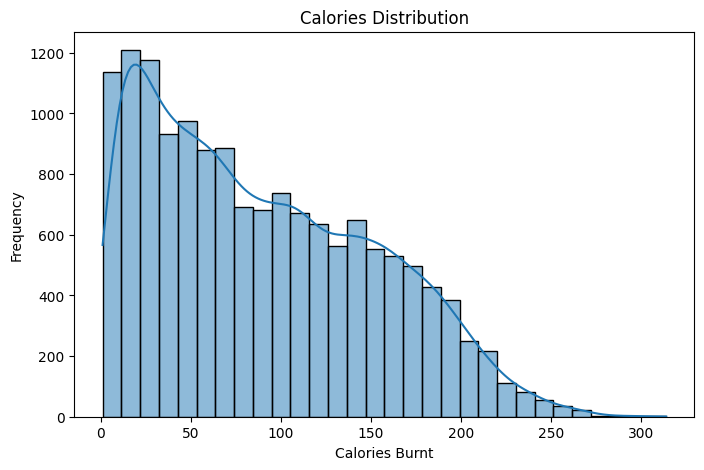

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Calories'], bins=30, kde=True)

plt.title("Calories Distribution")
plt.xlabel("Calories Burnt")
plt.ylabel("Frequency")

plt.show()

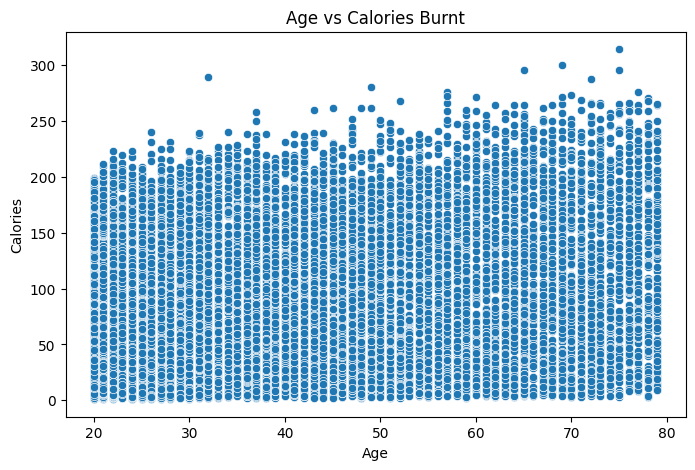

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Calories',
    data=df
)

plt.title("Age vs Calories Burnt")

plt.show()

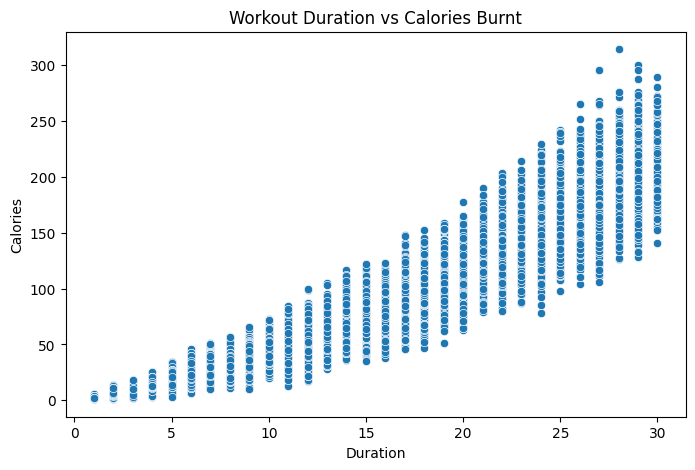

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Duration',
    y='Calories',
    data=df
)

plt.title("Workout Duration vs Calories Burnt")

plt.show()

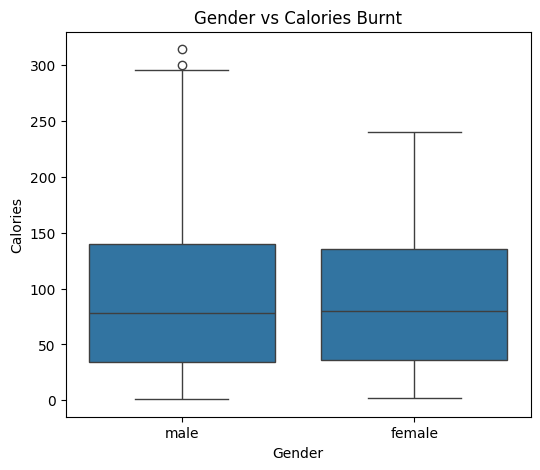

In [10]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Gender',
    y='Calories',
    data=df
)

plt.title("Gender vs Calories Burnt")

plt.show()

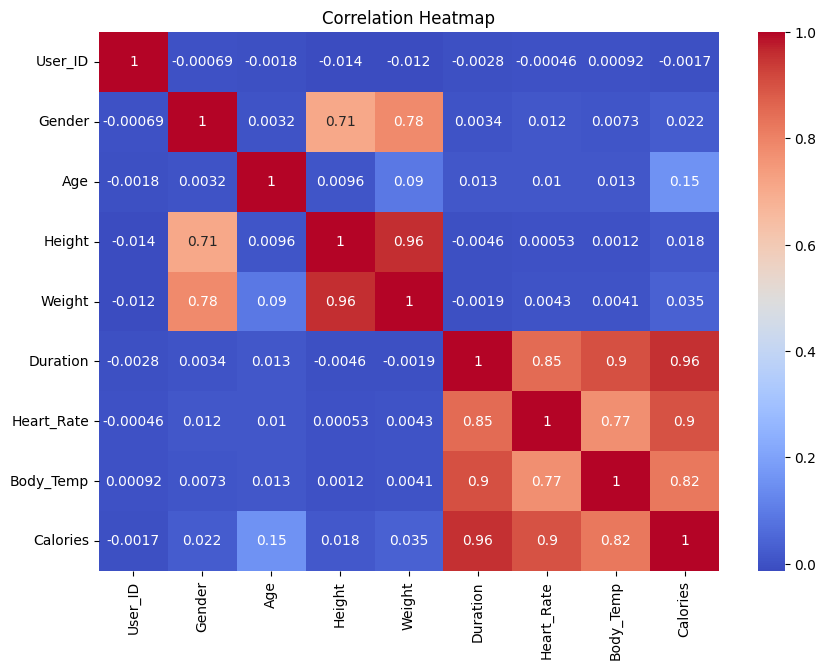

In [11]:
# Encode Gender temporarily

temp_df = df.copy()

encoder = LabelEncoder()

temp_df['Gender'] = encoder.fit_transform(temp_df['Gender'])

plt.figure(figsize=(10,7))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
# Encode Gender

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0


In [13]:
# Features and Target

X = df.drop(['User_ID', 'Calories'], axis=1)

y = df['Calories']

In [14]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# Initialize Model

model = RandomForestRegressor()

# Train Model

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# Predictions

y_pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)


Mean Absolute Error : 1.7075600000000002


In [18]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 7.161247400000001


In [19]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error :", rmse)

Root Mean Squared Error : 2.6760507095344814


In [20]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.9982255655575317


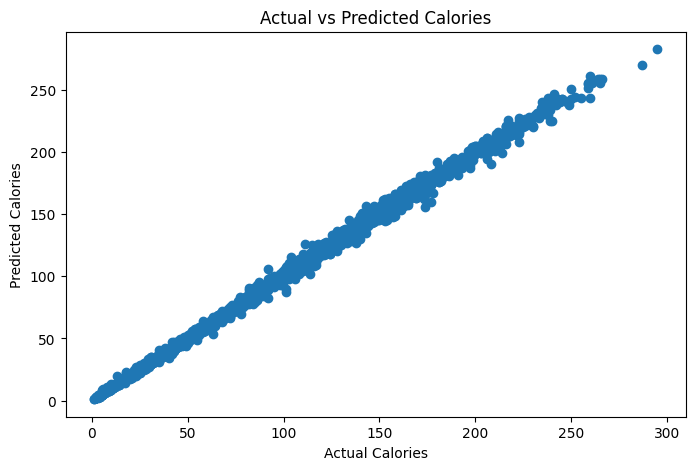

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")

plt.title("Actual vs Predicted Calories")

plt.show()


In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
4,Duration,0.914021
5,Heart_Rate,0.048069
1,Age,0.026375
0,Gender,0.006761
3,Weight,0.003025
2,Height,0.001266
6,Body_Temp,0.000483
